In [18]:
import polars as pl

in_pep = pl.read_parquet("../../data/in_v1/unclustered/in_v1_epitopes.parquet")
in_prot = pl.read_parquet(
    "../../data/in_v1/clustered/in_v1_proteins.clust.parquet"
)
hv_pep = pl.read_parquet("../../data/hv_v1/unclustered/hv_v1_epitopes.parquet")
hv_prot = pl.read_parquet(
    "../../data/hv_v1/clustered/hv_v1_proteins.clust.parquet"
)

Proteins that contained an epitope and a non-epitope + proteins that contain only non-epitopes


In [19]:
def concat_data(e_ne_df, ne_df):

    e_ne_df = e_ne_df.with_columns(
        (
            pl.col("epitope_30mer_segment_boolmask").list.sum()
            / pl.col("seq").str.len_chars()
        ).alias("ep_res_ratio"),
        pl.col("seq").str.len_chars().alias("seqlen"),
    ).select(
        [
            "seq",
            "seqlen",
            "ep_res_ratio",
        ]
    )

    ne_df = ne_df.with_columns(
        pl.col("seq").str.len_chars().alias("seqlen"),
        pl.lit(0.0).alias("ep_res_ratio"),
    ).select(
        [
            "seq",
            "seqlen",
            "ep_res_ratio",
        ]
    )
    return pl.concat([e_ne_df, ne_df])


def fmt_df(df):
    return df.with_columns(
        (
            pl.col("epitope_30mer_segment_boolmask").list.sum()
            / pl.col("seq").str.len_chars()
        ).alias("ep_res_ratio"),
        pl.col("seq").str.len_chars().alias("seqlen"),
    ).select(
        [
            "seq",
            "seqlen",
            "ep_res_ratio",
        ]
    )


in_df = fmt_df(in_prot)
hv_df = fmt_df(hv_prot)

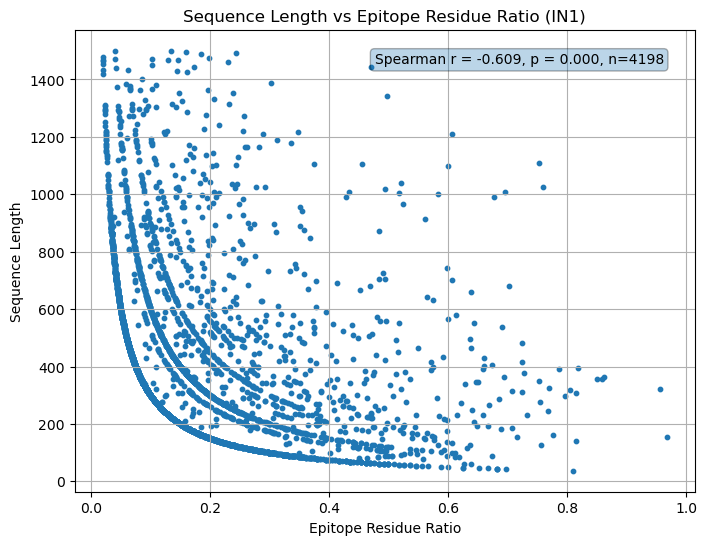

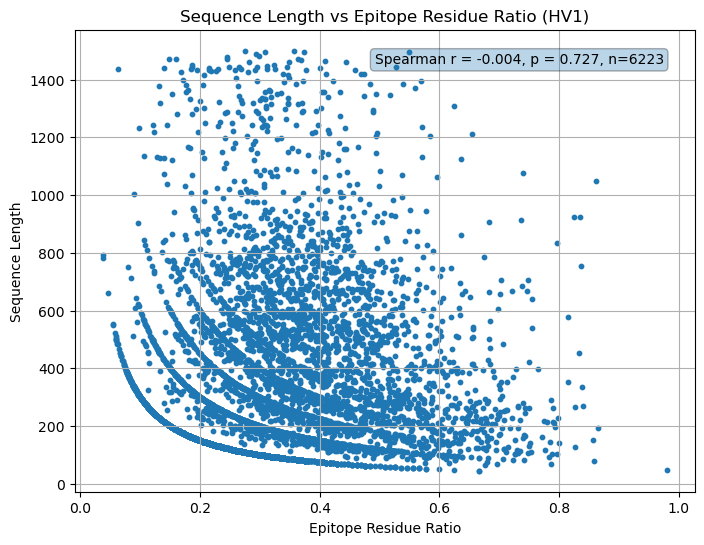

In [20]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


def seqlen_scatter(x, y, title):
    rho, pval = spearmanr(x, y)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x, y, alpha=1, s=10)
    ax.set_ylabel("Sequence Length")
    ax.set_xlabel("Epitope Residue Ratio")
    ax.set_title(title)

    text = f"Spearman r = {rho:.3f}, p = {pval:.3f}, n={len(x)}"
    plt.text(
        0.95,
        0.95,
        text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        ha="right",
        bbox=dict(boxstyle="round,pad=0.3", alpha=0.3),
    )
    plt.grid(True)
    plt.show()


seqlen_scatter(
    in_df["ep_res_ratio"],
    in_df["seqlen"],
    "Sequence Length vs Epitope Residue Ratio (IN1)",
)
seqlen_scatter(
    hv_df["ep_res_ratio"],
    hv_df["seqlen"],
    "Sequence Length vs Epitope Residue Ratio (HV1)",
)